In [1]:
import numpy as np
import pandas as pd

In [2]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [3]:
df = pd.read_csv("train2.csv",usecols=["Age","Fare","Survived"])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [7]:
df["Age"].fillna(df["Age"].mean(),inplace=True)

/tmp/ipykernel_5413/2595122914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [8]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [11]:
x

,Age,Fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


In [12]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [13]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [14]:
X_train.shape

(712, 2)

/tmp/ipykernel_5413/2307582215.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


Text(0.5, 1.0, 'Age QQ Plot')

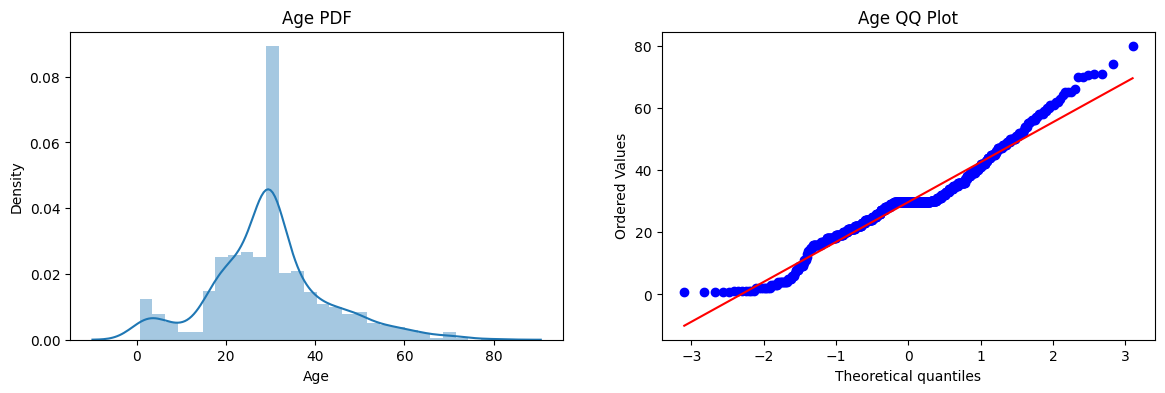

In [17]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train["Age"],dist="norm",plot=plt)
plt.title("Age QQ Plot")

/tmp/ipykernel_5413/3923844077.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Fare"])


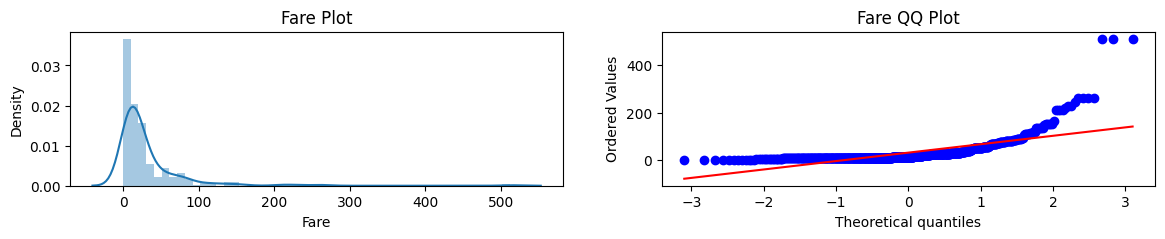

In [20]:
plt.figure(figsize=(14,2))
plt.subplot(121)
sns.distplot(X_train["Fare"])
plt.title("Fare Plot")

plt.subplot(122)
stats.probplot(X_train["Fare"],dist="norm",plot=plt)
plt.title("Fare QQ Plot")

plt.show()

In [26]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [27]:
clf.fit(X_train,Y_train)
clf2.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

In [29]:
print("Accuracy score for LR ",accuracy_score(Y_test,y_pred))
print("Accuracy score for DT ",accuracy_score(Y_test,y_pred1))

Accuracy score for LR  0.6983240223463687
Accuracy score for DT  0.6871508379888268


In [30]:
trf = FunctionTransformer(func=np.log1p) # 1p kun kunke some time if data mein 0 ho to us ko add + 1 krdo 

X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [31]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,Y_train)
clf2.fit(X_train_transformed,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf.predict(X_test_transformed)

In [34]:
print("Accuracy Score for LR ",accuracy_score(Y_test,y_pred))
print("Accuracy Score for DT ",accuracy_score(Y_test,y_pred1))

Accuracy Score for LR  0.7039106145251397
Accuracy Score for DT  0.7039106145251397


In [39]:
X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring="accuracy",cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring="accuracy",cv=10)))

LR 0.678027465667915
DT 0.6588514357053683


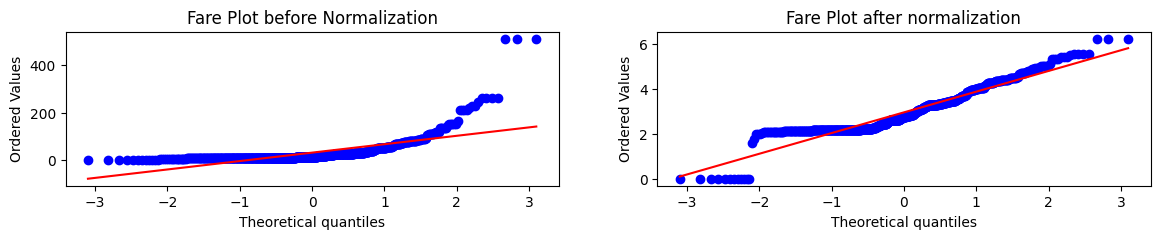

In [42]:
plt.figure(figsize=(14,2))
plt.subplot(121)
stats.probplot(X_train["Fare"],dist="norm",plot=plt)
plt.title("Fare Plot before Normalization")

plt.subplot(122)
stats.probplot(X_train_transformed["Fare"],dist="norm",plot=plt)
plt.title("Fare Plot after normalization")

plt.show()

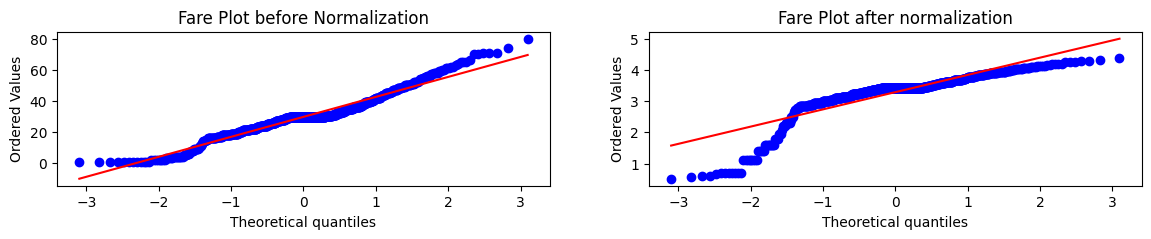

In [43]:
plt.figure(figsize=(14,2))
plt.subplot(121)
stats.probplot(X_train["Age"],dist="norm",plot=plt)
plt.title("Fare Plot before Normalization")

plt.subplot(122)
stats.probplot(X_train_transformed["Age"],dist="norm",plot=plt)
plt.title("Fare Plot after normalization")

plt.show()